In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [5]:
# Load the cleaned dataset
df = pd.read_csv("heart_disease_cleaned.csv")
print(f"Shape: {df.shape}")
print(f"\nTarget distribution:\n{df['HeartDiseaseorAttack'].value_counts()}")
print(f"\nPositive class rate: {df['HeartDiseaseorAttack'].mean():.2%}")

# Separate features and target
TARGET = 'HeartDiseaseorAttack'
X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f"Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")

Shape: (229781, 22)

Target distribution:
HeartDiseaseorAttack
0.0    206064
1.0     23717
Name: count, dtype: int64

Positive class rate: 10.32%
Features: 21
Samples: 229781


In [6]:
# Train / Validation / Test Split

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

# Second split: split the 30% into 15/15 (i.e., 50/50 of temp)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print("Split sizes:")
print(f"  Train: {X_train.shape[0]:,} ({X_train.shape[0]/len(df):.1%})")
print(f"  Val:   {X_val.shape[0]:,} ({X_val.shape[0]/len(df):.1%})")
print(f"  Test:  {X_test.shape[0]:,} ({X_test.shape[0]/len(df):.1%})")
print(f"\nPositive class rate per split:")
print(f"  Train: {y_train.mean():.2%}")
print(f"  Val:   {y_val.mean():.2%}")
print(f"  Test:  {y_test.mean():.2%}")


Split sizes:
  Train: 160,846 (70.0%)
  Val:   34,467 (15.0%)
  Test:  34,468 (15.0%)

Positive class rate per split:
  Train: 10.32%
  Val:   10.32%
  Test:  10.32%


In [7]:
# Feature Scaling
scaler = StandardScaler()

# Fit on train, transform all three
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_val_scaled = pd.DataFrame(
    scaler.transform(X_val), columns=X_val.columns, index=X_val.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=X_test.columns, index=X_test.index
)

print(f"Train mean (should be ~0): {X_train_scaled.mean().mean():.6f}")
print(f"Train std  (should be ~1): {X_train_scaled.std().mean():.6f}")
print(f"Val mean   (should be near 0): {X_val_scaled.mean().mean():.6f}")

Train mean (should be ~0): 0.000000
Train std  (should be ~1): 1.000003
Val mean   (should be near 0): -0.000832


In [8]:
# SMOTE (Training Set Only)
smote = SMOTE(random_state=RANDOM_STATE)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:")
print(f"  Train size: {X_train_scaled.shape[0]:,}")
print(f"  Class 0: {(y_train == 0).sum():,}  |  Class 1: {(y_train == 1).sum():,}")
print(f"\nAfter SMOTE:")
print(f"  Train size: {X_train_resampled.shape[0]:,}")
print(f"  Class 0: {(y_train_resampled == 0).sum():,}  |  Class 1: {(y_train_resampled == 1).sum():,}")
print(f"  Balance ratio: {(y_train_resampled == 0).sum() / (y_train_resampled == 1).sum():.2f}:1")

Before SMOTE:
  Train size: 160,846
  Class 0: 144,244  |  Class 1: 16,602

After SMOTE:
  Train size: 288,488
  Class 0: 144,244  |  Class 1: 144,244
  Balance ratio: 1.00:1


In [10]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    f1_score, precision_score, recall_score, RocCurveDisplay
)

# Define hyperparameter grid
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
}

rf_base = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

# 3-fold CV on the SMOTE'd training data
rf_grid = GridSearchCV(
    rf_base,
    rf_param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("Starting Random Forest grid search...")
rf_grid.fit(X_train_resampled, y_train_resampled)

print(f"\nBest params: {rf_grid.best_params_}")
print(f"Best CV AUC-ROC: {rf_grid.best_score_:.4f}")

Starting Random Forest grid search...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV AUC-ROC: 0.9875


In [11]:
# Evaluate on validation set (NOT resampled — real-world distribution)
rf_best = rf_grid.best_estimator_

rf_val_preds = rf_best.predict(X_val_scaled)
rf_val_probs = rf_best.predict_proba(X_val_scaled)[:, 1]

print("=== Random Forest — Validation Set Results ===\n")
print(classification_report(y_val, rf_val_preds, target_names=['No HD', 'Heart Disease']))
print(f"AUC-ROC:   {roc_auc_score(y_val, rf_val_probs):.4f}")
print(f"F1:        {f1_score(y_val, rf_val_preds):.4f}")
print(f"Precision: {precision_score(y_val, rf_val_preds):.4f}")
print(f"Recall:    {recall_score(y_val, rf_val_preds):.4f}")

=== Random Forest — Validation Set Results ===

               precision    recall  f1-score   support

        No HD       0.91      0.96      0.94     30910
Heart Disease       0.39      0.21      0.27      3557

     accuracy                           0.88     34467
    macro avg       0.65      0.58      0.60     34467
 weighted avg       0.86      0.88      0.87     34467

AUC-ROC:   0.8070
F1:        0.2693
Precision: 0.3866
Recall:    0.2066


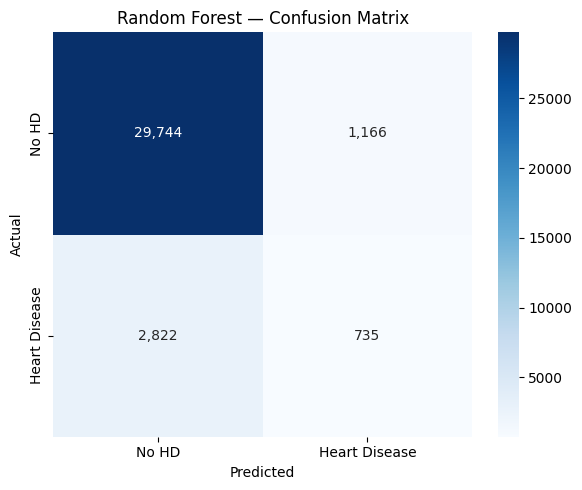

In [16]:
# Confusion matrix
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_val, rf_val_preds)
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=ax,
            xticklabels=['No HD', 'Heart Disease'],
            yticklabels=['No HD', 'Heart Disease'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

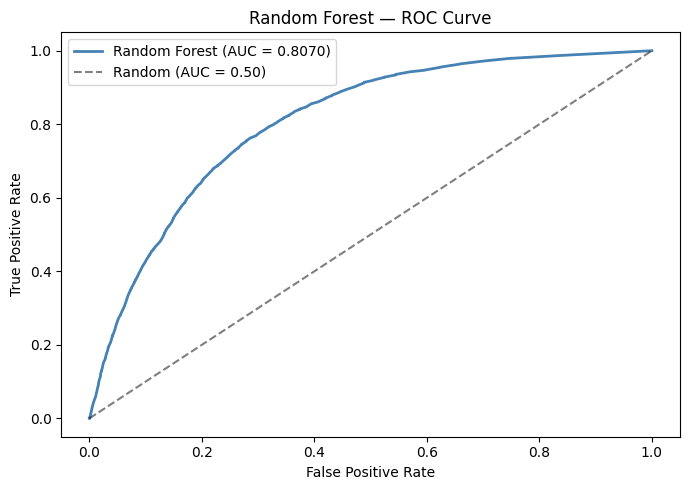

In [17]:
# ROC curve
fig, ax = plt.subplots(figsize=(7, 5))
rf_fpr, rf_tpr, _ = roc_curve(y_val, rf_val_probs)
rf_auc = roc_auc_score(y_val, rf_val_probs)
ax.plot(rf_fpr, rf_tpr, color='steelblue', lw=2, label=f'Random Forest (AUC = {rf_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC = 0.50)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Random Forest — ROC Curve')
ax.legend()
plt.tight_layout()
plt.show()